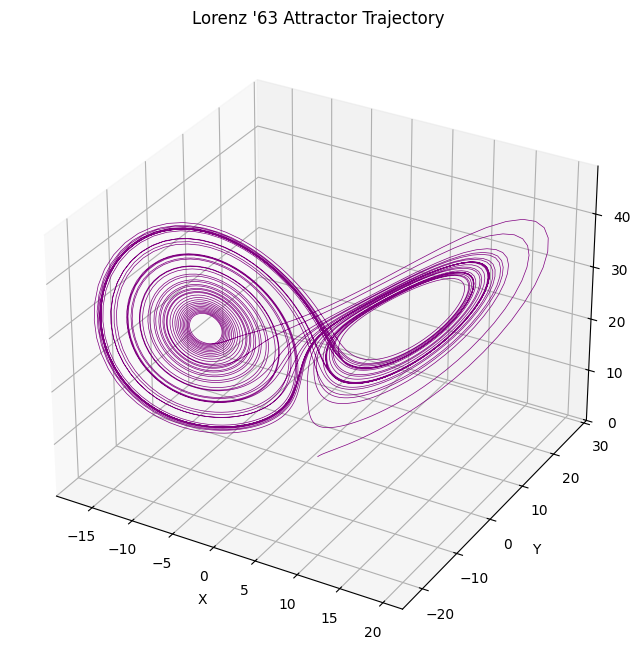

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure we can import from src directory
import sys
import os
if os.path.join(os.getcwd(), 'src') not in sys.path:
    sys.path.append(os.path.join(os.getcwd(), 'src'))

from le_calc.equations import Lorenz63
from le_calc.utils import integrate_ode

# Initialize Lorenz system
lorenz = Lorenz63()

# Define initial conditions and time span
x0 = [1.0, 1.0, 1.0]
t_span = (0, 50)
delta_t = 0.01

# Solve the ODE using our new utility function instead of inline solve_ivp
sol = integrate_ode(lorenz, x0, t_span, delta_t)

# Plot the trajectory in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5, color='purple')
ax.set_title("Lorenz '63 Attractor Trajectory")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()


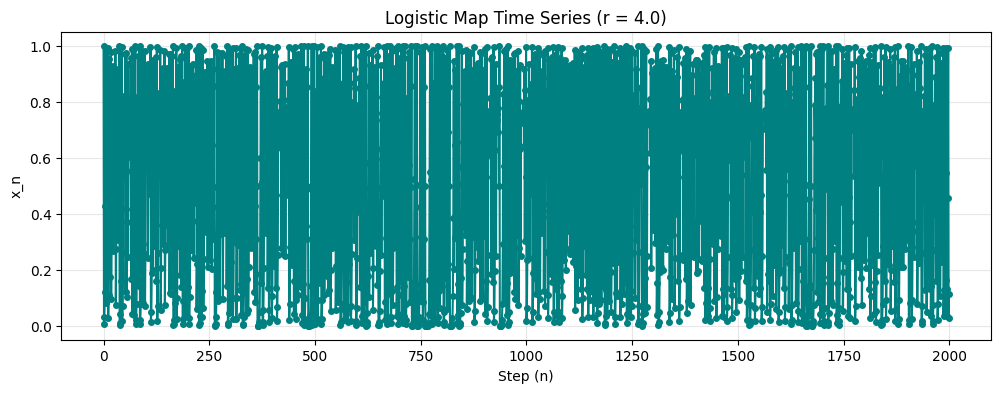

In [76]:
from le_calc.equations import LogisticMap

# Initialize chaotic Logistic Map (r = 4.0)
logistic = LogisticMap(r=4.0)

# Iterate the map
n_steps = 2000
x_history = np.zeros(n_steps)

# Discarding transients
x = 0.6
for i in range(n_steps//2):
    x = logistic.f(0, x)
for i in range(n_steps):
    x_history[i] = x
    x = logistic.f(0, x)

# Plot the time series iteration
fig, ax2 = plt.subplots(figsize=(12, 4))
ax2.plot(range(n_steps), x_history, marker='o', markersize=4, linestyle='-', color='teal')
ax2.set_title("Logistic Map Time Series (r = 4.0)")
ax2.set_xlabel("Step (n)")
ax2.set_ylabel("x_n")
ax2.grid(True, alpha=0.3)
plt.show()


0.6943463409682138


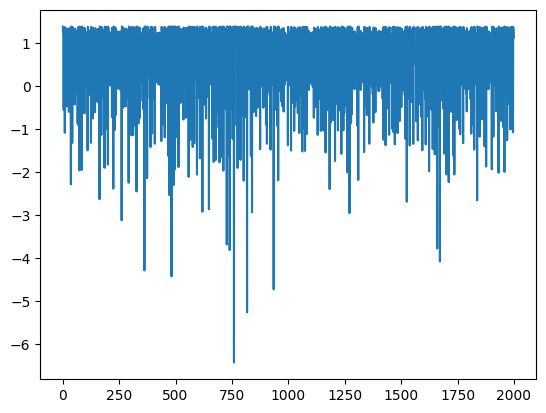

In [78]:
dim = 1
logJ_history = np.zeros((n_steps,dim))

for i in range(n_steps):
    logJ_history[i] = np.log(np.abs(logistic.jac(0,x_history[i])))

plt.plot(logJ_history)
print(np.mean(logJ_history))

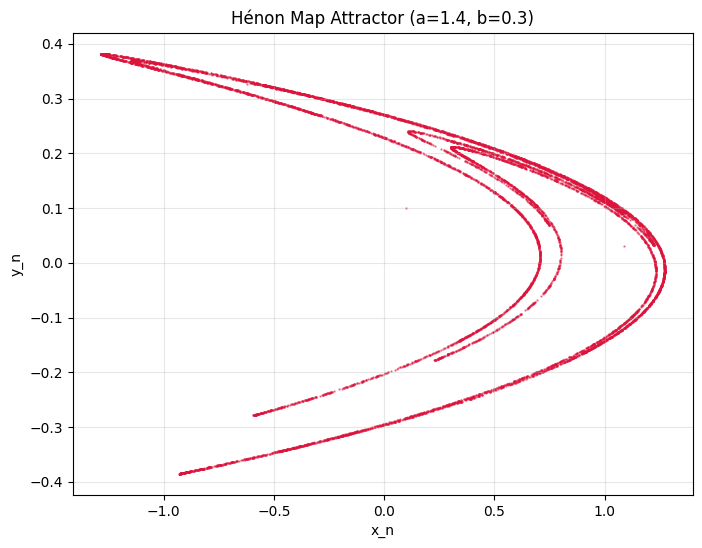

In [ ]:
from le_calc.equations import HenonMap

# Initialize chaotic Hénon Map (default a=1.4, b=0.3)
henon = HenonMap()

# Iterate the map
n_steps = 10000
dim = 2
x_history = np.zeros((n_steps,2))
state = np.array([0.1, 0.1])  # Initial condition


# Discarding transients
x = 0.6
for i in range(n_steps//20):
    x = logistic.f(0, x)
for i in range(n_steps):
    x_history[i] = state[0]
    y_history[i] = state[1]
    state = henon.f(0, state)

# Plot the Hénon attractor as a scatter plot
fig, ax3 = plt.subplots(figsize=(8, 6))
ax3.scatter(x_history, y_history, s=0.5, color='crimson', alpha=0.5)
ax3.set_title('Hénon Map Attractor (a=1.4, b=0.3)')
ax3.set_xlabel('x_n')
ax3.set_ylabel('y_n')
ax3.grid(True, alpha=0.3)
plt.show()


In [ ]:
dim = 1
logJ_history = np.zeros((n_steps,dim))

for i in range(n_steps):
    logJ_history[i] = np.log(np.abs(logistic.jac(0,x_history[i])))

plt.plot(logJ_history)
print(np.mean(logJ_history))